In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
with open("outputs/2026-06-15/14-03-29/training_log.json", "r") as f:
    training_logs = json.load(f)["epoch_logs"]
training_logs

{'1': {'timestamp': '2026-06-15T14:03:33.749409',
  'current_learning_rate': 0.0005,
  'training': {'loss': 1.287180128498611,
   'reg': 3.7042530224702013,
   'time_seconds': 3.1354713439941406,
   'memory_reserved_mb': 4256.0,
   'memory_allocated_mb': 219.44921875},
  'validation': {'metrics': {'MRR': 0.08884784579277039,
    'Hit@1': 0.08091674745082855,
    'Hit@3': 0.09401309490203857,
    'Hit@10': 0.09927502274513245},
   'time_seconds': 0.6622309684753418,
   'memory_reserved_mb': 4256.0,
   'memory_allocated_mb': 249.44921875}},
 '2': {'timestamp': '2026-06-15T14:03:38.234152',
  'current_learning_rate': 0.000499969466539211,
  'training': {'loss': 1.0182929975964201,
   'reg': 2.0325332597037375,
   'time_seconds': 2.981019973754883,
   'memory_reserved_mb': 4258.0,
   'memory_allocated_mb': 249.44921875},
  'validation': {'metrics': {'MRR': 0.10625587403774261,
    'Hit@1': 0.09155753254890442,
    'Hit@3': 0.11517773568630219,
    'Hit@10': 0.12745556235313416},
   'time_s

In [3]:
training_metrics = {
    epoch: {
        "loss": log["training"]["loss"],
        "Val MRR": log["validation"]["metrics"]["MRR"],
        "Val Hit@1": log["validation"]["metrics"]["Hit@1"],
        "Val Hit@3": log["validation"]["metrics"]["Hit@3"],
        "Val Hit@10": log["validation"]["metrics"]["Hit@10"],
    }
    for epoch, log in training_logs.items()
}
training_metrics = pd.DataFrame.from_dict(training_metrics, orient="index")
training_metrics
# pd.DataFrame.from_dict(training_loss, orient="index").plot()

,loss,Val MRR,Val Hit@1,Val Hit@3,Val Hit@10
1,1.287180,0.088848,0.080917,0.094013,0.099275
2,1.018293,0.106256,0.091558,0.115178,0.127456
3,0.959609,0.113985,0.097404,0.124649,0.139383
4,0.919167,0.115041,0.097170,0.126286,0.143241
5,0.886225,0.118448,0.100210,0.128976,0.149673
...,...,...,...,...,...
1368,0.482091,0.111863,0.101614,0.114476,0.128976
1369,0.481987,0.111914,0.101848,0.114125,0.129677
1370,0.484019,0.111900,0.101614,0.114710,0.129443
1371,0.481464,0.112164,0.102081,0.114827,0.128976


<Axes: title={'center': 'Loss'}>

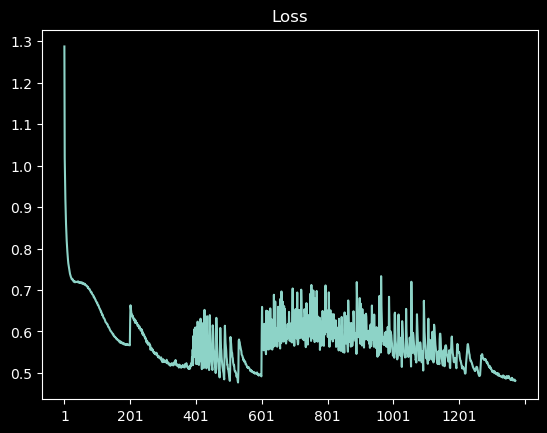

In [4]:
training_metrics["loss"].plot(title="Loss")

<Axes: title={'center': 'Validation Hit@10'}>

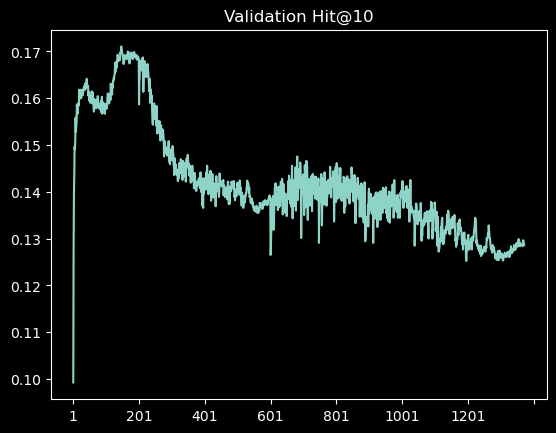

In [5]:
training_metrics["Val Hit@10"].plot(title="Validation Hit@10")

<Axes: title={'center': 'Validation MRR'}>

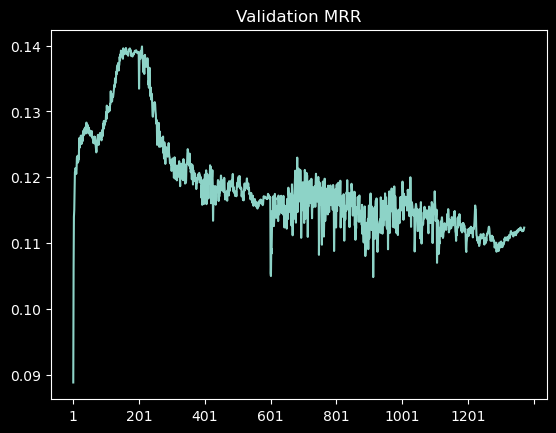

In [6]:
training_metrics["Val MRR"].plot(title="Validation MRR")